<a href="https://colab.research.google.com/github/OlhaZahrebelna/Intelligent-Support-Ticket-Router-using-NLP/blob/main/notebook/02_Preprocessing_and_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing and Classical Baseline Models

This notebook develops and evaluates classical NLP baselines for support-ticket routing.


## Import Libraries

In [1]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 76.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import re

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import spacy
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

## Load the Dataset

In [3]:
df = pd.read_csv("/content/customer_support_tickets_cleaned.csv")

## Explore the Dataset

In [4]:
df.head()

,text,subject,body,queue,priority,type,language
0,"Account Disruption Dear Customer Support Team,...",Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident,en
1,Query About Smart Home System Integration Feat...,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request,en
2,Inquiry Regarding Invoice Details Dear Custome...,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request,en
3,Question About Marketing Agency Software Compa...,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem,en
4,"Feature Query Dear Customer Support,\n\nI hope...",Feature Query,"Dear Customer Support,\n\nI hope this message ...",Technical Support,high,Request,en


In [5]:
df.shape

(23748, 7)

#### Check missing values

In [6]:
df.isnull().sum()

,0
text,0
subject,2827
body,1
queue,0
priority,0
type,0
language,0


In [7]:
df.duplicated().sum()

np.int64(0)

## Define Features and Target

`X` contains the ticket text used as model input.
`y` contains the queue labels that the model needs to predict.

In [8]:
X = df["text"]
y = df["queue"]
record_id = df.index

## Stratified Train–Validation–Test Split

The data is first divided into training and test sets. The training portion is then split again into training and validation subsets for the initial baseline comparison.

Stratification preserves the class distribution across all subsets, which is important because the queue labels are imbalanced. The test set remains untouched until the final model has been selected.

In [9]:
X_train_full, X_test, y_train_full, y_test, id_train_full, id_test = (
    train_test_split(
        X,
        y,
        record_id,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

### Split Conclusion

The final dataset contains **23,748** records. The first stratified split allocates **18,998** records to `X_train_full` and **4,750** records to the untouched test set. The second split produces **15,198** training records and **3,800** validation records.

This corresponds to approximately **64% training, 16% validation, and 20% test data**. Because the text, label, and `record_id` arrays are split together, their row-level correspondence is preserved. Stratification also ensures that minority classes remain represented in every subset.

## Text Preprocessing

The custom `TextPreprocessor` class is compatible with scikit-learn pipelines.
This is important because preprocessing must be applied only inside the training pipeline, avoiding data leakage.

The class performs:

- lowercasing;
- URL removal;
- email removal;
- whitespace normalization;
- lemmatization with spaCy;
- stopword removal;
- removal of numbers and non-alphabetic tokens;
- removal of very short tokens.

In [10]:
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"],
)


NEGATION_WORDS = {
    "no",
    "not",
    "never",
    "cannot",
    "n't",
}


class TextPreprocessor(BaseEstimator, TransformerMixin):
    """
    Preprocessing transformer for English support-ticket texts.

    Steps:
    1. Convert values to strings.
    2. Normalize contractions and negations.
    3. Remove URLs and email addresses.
    4. Apply spaCy tokenization and lemmatization.
    5. Remove stop words, except meaningful negations.
    6. Keep alphabetic tokens only.
    """

    def __init__(
        self,
        min_token_len=2,
        batch_size=500,
    ):
        self.min_token_len = min_token_len
        self.batch_size = batch_size

    def fit(self, X, y=None):
        return self

    @staticmethod
    def normalize_text(text):
        """
        Normalize common English contractions before spaCy processing.
        """

        text = str(text)

        # Normalize apostrophes.
        text = text.replace("’", "'")
        text = text.replace("`", "'")

        # Important irregular negations.
        text = re.sub(
            r"\bcan't\b",
            "cannot",
            text,
            flags=re.IGNORECASE,
        )

        text = re.sub(
            r"\bwon't\b",
            "will not",
            text,
            flags=re.IGNORECASE,
        )

        text = re.sub(
            r"\bshan't\b",
            "shall not",
            text,
            flags=re.IGNORECASE,
        )

        # General negation contractions:
        # isn't -> is not
        # didn't -> did not
        # couldn't -> could not
        # doesn't -> does not
        text = re.sub(
            r"n['’]t\b",
            " not",
            text,
            flags=re.IGNORECASE,
        )

        # Remove URLs.
        text = re.sub(
            r"https?://\S+|www\.\S+",
            " ",
            text,
        )

        # Remove email addresses.
        text = re.sub(
            r"\b[\w.\-+]+@[\w.\-]+\.\w+\b",
            " ",
            text,
        )

        # Remove unnecessary whitespace.
        text = re.sub(r"\s+", " ", text).strip()

        return text

    def transform(self, X):
        """
        Transform an iterable of texts into cleaned strings.
        """

        texts = [
            self.normalize_text(text)
            if text is not None and not (
                isinstance(text, float) and np.isnan(text)
            )
            else ""
            for text in X
        ]

        processed_texts = []

        docs = nlp.pipe(
            texts,
            batch_size=self.batch_size,
        )

        for doc in docs:
            tokens = []

            for token in doc:
                token_text = token.text.lower().strip()
                lemma = token.lemma_.lower().strip()

                # spaCy can occasionally return an empty lemma.
                if not lemma:
                    continue

                # Preserve negation either by original token
                # or by its lemma.
                is_negation = (
                    token_text in NEGATION_WORDS
                    or lemma in NEGATION_WORDS
                )

                # Keep only alphabetic words and explicit negations.
                # "n't" is not alphabetic, so is_negation is checked separately.
                is_valid_token = token.is_alpha or is_negation

                if not is_valid_token:
                    continue

                # Remove stop words, except negations.
                if token.is_stop and not is_negation:
                    continue

                # Do not remove short negations such as "no".
                if len(lemma) < self.min_token_len and not is_negation:
                    continue

                # Normalize all negative forms to "not",
                # except "no" and "never", which preserve different meanings.
                if token_text in {"n't", "cannot"} or lemma == "cannot":
                    lemma = "not"

                tokens.append(lemma)

            processed_texts.append(" ".join(tokens))

        return np.asarray(processed_texts)

In [11]:
examples = [
    "It is not possible to access my account.",
    "I can't log into my profile.",
    "The payment was never received.",
    "No confirmation email has arrived.",
    "The application isn't working.",
    "I won't be able to complete the payment.",
]

preprocessor = TextPreprocessor()

processed_examples = preprocessor.fit_transform(examples)

for original, processed in zip(examples, processed_examples):
    print("Original: ", original)
    print("Processed:", processed)
    print("-" * 60)

Original:  It is not possible to access my account.
Processed: not possible access account
------------------------------------------------------------
Original:  I can't log into my profile.
Processed: not log profile
------------------------------------------------------------
Original:  The payment was never received.
Processed: payment never receive
------------------------------------------------------------
Original:  No confirmation email has arrived.
Processed: no confirmation email arrive
------------------------------------------------------------
Original:  The application isn't working.
Processed: application not work
------------------------------------------------------------
Original:  I won't be able to complete the payment.
Processed: not able complete payment
------------------------------------------------------------


### Preprocessing Rationale

This preprocessing pipeline is designed for a traditional TF-IDF and linear-classifier baseline. It reduces vocabulary noise through lowercasing, lemmatization, stop-word removal, and punctuation filtering while preserving meaningful negation terms such as no, not, and never. Numeric, alphanumeric, and non-alphabetic tokens are removed.

## TF-IDF

TF-IDF converts cleaned text into sparse numerical vectors.
Terms that are frequent in a specific ticket but not too common across all tickets receive higher weights.

This representation is a strong baseline for classical machine learning models in text classification.

## Baseline Model: Logistic Regression

Logistic Regression is a good first baseline for text classification because it is fast, interpretable, and works well with sparse TF-IDF features.

In [12]:
logreg_pipeline = Pipeline([
    ("preprocessing", TextPreprocessor()),
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [13]:
logreg_pipeline.fit(X_train, y_train)

y_train_pred_log = logreg_pipeline.predict(X_train)
y_val_pred_log = logreg_pipeline.predict(X_val)

## Logistic Regression Metrics

Macro F1 is especially important here because the dataset is likely imbalanced.
It gives equal weight to each class, so poor performance on minority classes is not hidden by strong performance on large classes.

In [14]:
print("Logistic Regression")
print(classification_report(y_val, y_val_pred_log))

print("Macro F1 Train:",
      f1_score(y_train, y_train_pred_log, average="macro"))
print("Macro F1 Val:",
      f1_score(y_val, y_val_pred_log, average="macro"))

Logistic Regression
                                 precision    recall  f1-score   support

           Billing and Payments       0.83      0.66      0.74       387
               Customer Service       0.33      0.35      0.34       571
                General Inquiry       1.00      0.02      0.04        55
                Human Resources       0.89      0.11      0.19        74
                     IT Support       0.46      0.21      0.29       453
                Product Support       0.38      0.38      0.38       709
          Returns and Exchanges       0.60      0.10      0.17       188
            Sales and Pre-Sales       0.88      0.12      0.21       116
Service Outages and Maintenance       0.75      0.44      0.55       150
              Technical Support       0.43      0.72      0.54      1097

                       accuracy                           0.45      3800
                      macro avg       0.66      0.31      0.35      3800
                   weighted a

## Experiment 2: Logistic Regression with Tuned TF-IDF Features

This experiment modifies both the TF-IDF representation and the classifier settings:

- `ngram_range=(1, 2)`: includes unigrams and bigrams, such as `password reset` or `billing issue`;
- `min_df=5`: removes terms that occur in fewer than five documents;
- `max_df=0.95`: removes extremely common terms;
- `max_features=50_000`: limits the vocabulary size;
- `sublinear_tf=True`: reduces the influence of repeated terms;
- `class_weight="balanced"`: increases the relative importance of minority classes;
- `C=0.1`: applies stronger regularization.


In [15]:
logreg_pipeline2 = Pipeline([
    ("preprocessing", TextPreprocessor()),
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95,
        max_features=50_000,
        sublinear_tf=True
    )),
    ("classifier", LogisticRegression(
        max_iter=2_000,
        class_weight="balanced",
        C=0.1
    ))
])

In [16]:
logreg_pipeline2.fit(X_train, y_train)

y_train_pred_log2 = logreg_pipeline2.predict(X_train)
y_val_pred_log2 = logreg_pipeline2.predict(X_val)

## Evaluation of Tuned Logistic Regression


In [17]:
print("Logistic Regression with balanced class weights")
print(classification_report(y_val, y_val_pred_log2))

print("Macro F1 Train:",
      f1_score(y_train, y_train_pred_log2, average="macro"))
print("Macro F1 Val:",
      f1_score(y_val, y_val_pred_log2, average="macro"))

Logistic Regression with balanced class weights
                                 precision    recall  f1-score   support

           Billing and Payments       0.76      0.66      0.70       387
               Customer Service       0.30      0.21      0.25       571
                General Inquiry       0.08      0.44      0.13        55
                Human Resources       0.15      0.46      0.23        74
                     IT Support       0.37      0.29      0.32       453
                Product Support       0.41      0.12      0.19       709
          Returns and Exchanges       0.20      0.26      0.22       188
            Sales and Pre-Sales       0.12      0.54      0.19       116
Service Outages and Maintenance       0.39      0.64      0.48       150
              Technical Support       0.50      0.43      0.46      1097

                       accuracy                           0.35      3800
                      macro avg       0.33      0.40      0.32      3800
 

### Logistic Regression Comparison

The tuned Logistic Regression did **not** improve the validation Macro F1 score. Macro F1 decreased from **0.345** for the default model to **0.318** for the balanced and regularized configuration. Although recall increased for several minority classes, this came with a substantial loss of precision and lower overall accuracy.

This result shows that class balancing and more complex TF-IDF features do not automatically improve performance. The default Logistic Regression therefore remains the stronger of the two Logistic Regression baselines, while Linear SVM should be evaluated as the next classical model.

## Baseline Model 2: Linear SVM

Linear SVM is often very strong for sparse high-dimensional text features.
It tries to find a separating hyperplane with a large margin between classes.

In [18]:
svm_pipeline = Pipeline([
    ("preprocessing", TextPreprocessor()),
    ("tfidf", TfidfVectorizer()),
    ("classifier", LinearSVC())
])

In [19]:
svm_pipeline.fit(X_train, y_train)
y_train_pred_svm = svm_pipeline.predict(X_train)
y_pred_svm = svm_pipeline.predict(X_val)

## Linear SVM Metrics

These metrics are compared with Logistic Regression to identify the stronger baseline model.

In [20]:
print("Linear SVM")
print(classification_report(y_val, y_pred_svm))

print("Macro F1 Train:",
      f1_score(y_train, y_train_pred_svm, average="macro"))
print("Macro F1 Val:",
      f1_score(y_val, y_pred_svm, average="macro"))

Linear SVM
                                 precision    recall  f1-score   support

           Billing and Payments       0.78      0.72      0.75       387
               Customer Service       0.37      0.40      0.39       571
                General Inquiry       0.48      0.20      0.28        55
                Human Resources       0.61      0.31      0.41        74
                     IT Support       0.43      0.30      0.35       453
                Product Support       0.40      0.39      0.39       709
          Returns and Exchanges       0.43      0.21      0.28       188
            Sales and Pre-Sales       0.53      0.28      0.36       116
Service Outages and Maintenance       0.65      0.57      0.60       150
              Technical Support       0.47      0.64      0.54      1097

                       accuracy                           0.47      3800
                      macro avg       0.51      0.40      0.44      3800
                   weighted avg       

### Linear SVM Conclusion
The untuned Linear SVM achieved a validation Macro F1 of **0.4360** , improving on the default Logistic Regression score of **0.3452**. It also produced higher F1 scores for several minority classes, including General Inquiry, Human Resources, Returns and Exchanges, and Sales and Pre-Sales.
However, its training Macro F1 of **0.7041** was substantially higher than its validation score, indicating a considerable generalization gap and probable overfitting. Linear SVM was therefore selected as the strongest initial classical model, but its regularization and TF-IDF parameters required systematic selection through cross-validation rather than evaluation on a single validation split.

## Hyperparameter-Tuned Linear SVM with Cross-Validation

The initial Linear SVM achieved a validation Macro F1 of **0.4360**, but its training Macro F1 was substantially higher (**0.7041**), indicating a large generalization gap. To improve model selection, the next experiment:

- keeps the test set untouched;
- tunes the regularization parameter `C` with stratified cross-validation;
- tests different TF-IDF vocabulary sizes and minimum document frequencies;
- compares unigram and unigram–bigram representations;
- selects the configuration with the highest mean cross-validation Macro F1.

In [21]:
svm_search_pipeline = Pipeline([
    ("preprocessing", TextPreprocessor()),
    ("tfidf", TfidfVectorizer(
        max_df=0.95,
        sublinear_tf=True
    )),
    ("classifier", LinearSVC(
        class_weight="balanced"
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [5, 10],
    "tfidf__max_features": [30_000, 50_000],
    "classifier__C": [0.05, 0.1, 0.2]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=svm_search_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    verbose=2,
    return_train_score=True,
    refit=True
)


grid_search.fit(X_train_full, y_train_full)

print("Best parameters:", grid_search.best_params_)
print(f"Best mean CV Macro F1: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END classifier__C=0.05, tfidf__max_features=30000, tfidf__min_df=5, tfidf__ngram_range=(1, 1); total time= 1.7min
[CV] END classifier__C=0.05, tfidf__max_features=30000, tfidf__min_df=5, tfidf__ngram_range=(1, 1); total time= 1.6min
[CV] END classifier__C=0.05, tfidf__max_features=30000, tfidf__min_df=5, tfidf__ngram_range=(1, 1); total time= 1.7min
[CV] END classifier__C=0.05, tfidf__max_features=30000, tfidf__min_df=5, tfidf__ngram_range=(1, 2); total time= 1.9min
[CV] END classifier__C=0.05, tfidf__max_features=30000, tfidf__min_df=5, tfidf__ngram_range=(1, 2); total time= 1.6min
[CV] END classifier__C=0.05, tfidf__max_features=30000, tfidf__min_df=5, tfidf__ngram_range=(1, 2); total time= 1.7min
[CV] END classifier__C=0.05, tfidf__max_features=30000, tfidf__min_df=10, tfidf__ngram_range=(1, 1); total time= 1.6min
[CV] END classifier__C=0.05, tfidf__max_features=30000, tfidf__min_df=10, tfidf__ngram_range=(1, 1); tota

## Cross-Validation Performance and Generalization Gap

For the selected configuration, both mean training and mean validation Macro F1 are reported across the cross-validation folds. The gap helps diagnose overfitting, while mean validation Macro F1 remains the main model-selection metric.

In [22]:
cv_results = pd.DataFrame(grid_search.cv_results_)
best_cv_row = cv_results.loc[grid_search.best_index_]

mean_train_f1 = best_cv_row["mean_train_score"]
mean_val_f1 = best_cv_row["mean_test_score"]
cv_gap = mean_train_f1 - mean_val_f1

print(f"Mean CV Train Macro F1: {mean_train_f1:.4f}")
print(f"Mean CV Validation Macro F1: {mean_val_f1:.4f}")
print(f"Mean CV Generalization Gap: {cv_gap:.4f}")

Mean CV Train Macro F1: 0.8519
Mean CV Validation Macro F1: 0.4801
Mean CV Generalization Gap: 0.3718


## Final Evaluation on the Untouched Test Set

After cross-validation and hyperparameter selection, the best pipeline is evaluated once on the test set. Because the test data was not used for model selection, these results provide the final estimate of out-of-sample performance for the classical baseline.

### Cross-Validation Conclusion

Cross-Validation Conclusion
The selected configuration achieved a mean cross-validation training Macro F1 of **0.8519** and a mean cross-validation validation Macro F1 of **0.4801**, resulting in a generalization gap of **0.3718**.
This substantial gap indicates that the model fits the training folds considerably better than unseen validation folds and therefore remains prone to overfitting. Nevertheless, cross-validation provides a more robust basis for hyperparameter selection than a single train–validation split because performance is evaluated across multiple stratified data partitions.
The results also suggest that increasing model complexity or adjusting regularization alone may not be sufficient. Further error analysis should examine class imbalance, semantic overlap between queue labels, ambiguous ticket content, label consistency, and the availability of representative examples for minority classes.

In [23]:
final_model = grid_search.best_estimator_

y_train_full_pred = final_model.predict(X_train_full)
y_test_pred = final_model.predict(X_test)

train_f1 = f1_score(y_train_full, y_train_full_pred, average="macro")
test_f1 = f1_score(y_test, y_test_pred, average="macro")
final_gap = train_f1 - test_f1

print("Final Regularized Linear SVM")
print(classification_report(y_test, y_test_pred, zero_division=0))
print(f"Macro F1 Train: {train_f1:.4f}")
print(f"Macro F1 Test: {test_f1:.4f}")
print(f"Final Generalization Gap: {final_gap:.4f}")

Final Regularized Linear SVM
                                 precision    recall  f1-score   support

           Billing and Payments       0.79      0.82      0.81       484
               Customer Service       0.52      0.50      0.51       714
                General Inquiry       0.38      0.51      0.43        68
                Human Resources       0.45      0.70      0.55        92
                     IT Support       0.49      0.46      0.47       567
                Product Support       0.56      0.46      0.51       886
          Returns and Exchanges       0.43      0.63      0.51       235
            Sales and Pre-Sales       0.33      0.61      0.43       145
Service Outages and Maintenance       0.52      0.73      0.61       187
              Technical Support       0.65      0.56      0.60      1372

                       accuracy                           0.56      4750
                      macro avg       0.51      0.60      0.54      4750
                   w

In [24]:
svm_test_predictions = pd.DataFrame({
    "record_id": id_test.to_numpy(),
    "text": X_test.astype(str).to_numpy(),
    "true_label": y_test.to_numpy(),
    "svm_pred": y_test_pred
})

svm_test_predictions["svm_correct"] = (
    svm_test_predictions["svm_pred"]
    == svm_test_predictions["true_label"]
)

svm_test_predictions.to_csv(
    "svm_test_predictions.csv",
    index=False
)

In [25]:
assert len(svm_test_predictions) == len(X_test)
assert svm_test_predictions["record_id"].is_unique
assert svm_test_predictions["true_label"].notna().all()
assert svm_test_predictions["svm_pred"].notna().all()

print("Rows:", len(svm_test_predictions))
print(
    "Unique record IDs:",
    svm_test_predictions["record_id"].nunique(),
)
print("svm_test_predictions.csv created successfully.")

Rows: 4750
Unique record IDs: 4750
svm_test_predictions.csv created successfully.


### Error Analysis

The final regularized Linear SVM achieved a test Macro F1 score of **0.5427**. The model performed best on **Billing and Payments** (F1 = 0.81), where tickets contain relatively distinctive vocabulary. In contrast, the weakest results were observed for **Sales and Pre-Sales** (F1 = 0.43), **IT Support** (F1 = 0.47), and **General Inquiry** (F1 = 0.43).

Most errors are likely caused by semantic overlap between related categories, especially **IT Support**, **Technical Support**, **Product Support**, and **Customer Service**. Short or vague tickets may not contain enough category-specific keywords for a TF-IDF model to distinguish them reliably. Several minority classes also show high recall but low precision, indicating that class balancing causes the model to overpredict them.

The difference between train Macro F1 (**0.86**) and test Macro F1 (**0.54**) shows that overfitting remains present despite regularization. Overall, the model provides a reasonable classical baseline, but a contextual model such as BERT may better capture semantic differences between overlapping ticket categories.


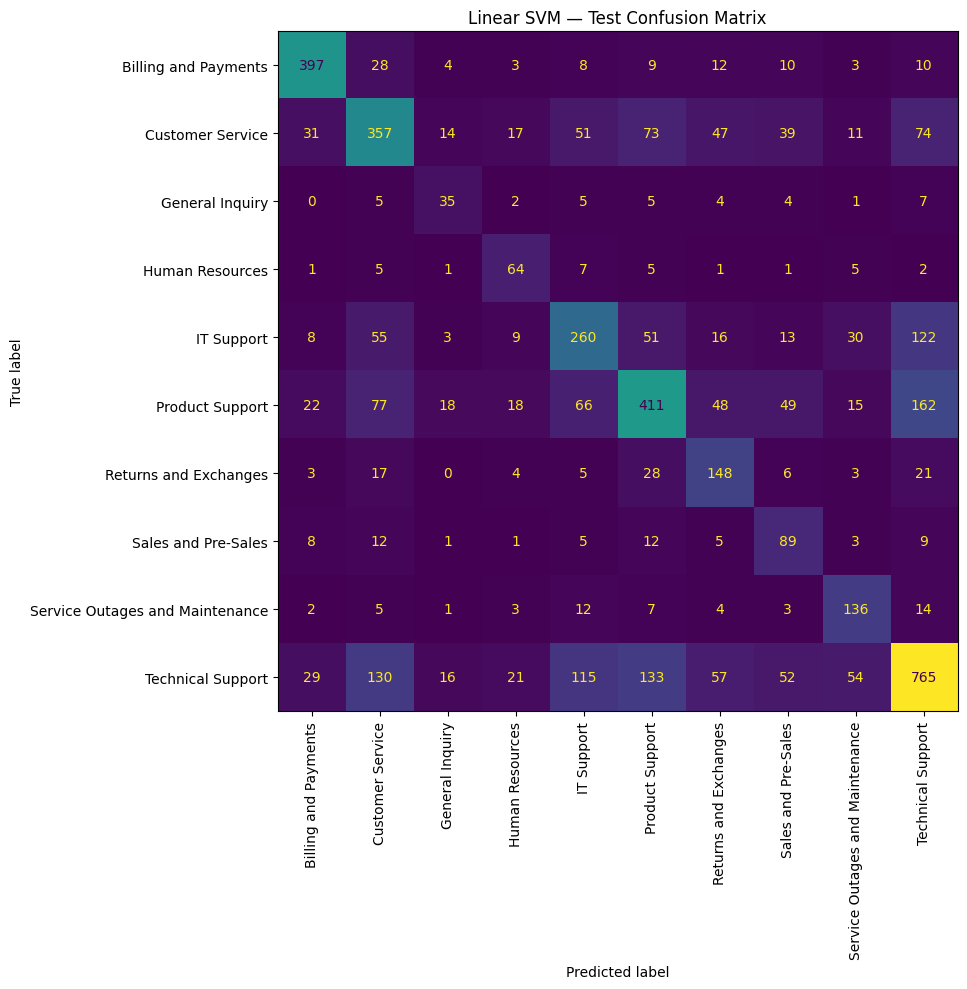

In [26]:
class_labels = final_model.named_steps[
    "classifier"
].classes_

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=class_labels,
)

fig, ax = plt.subplots(figsize=(12, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels,
)

display.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d",
    colorbar=False,
)

ax.set_title(
    "Linear SVM — Test Confusion Matrix"
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.savefig(
    "svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

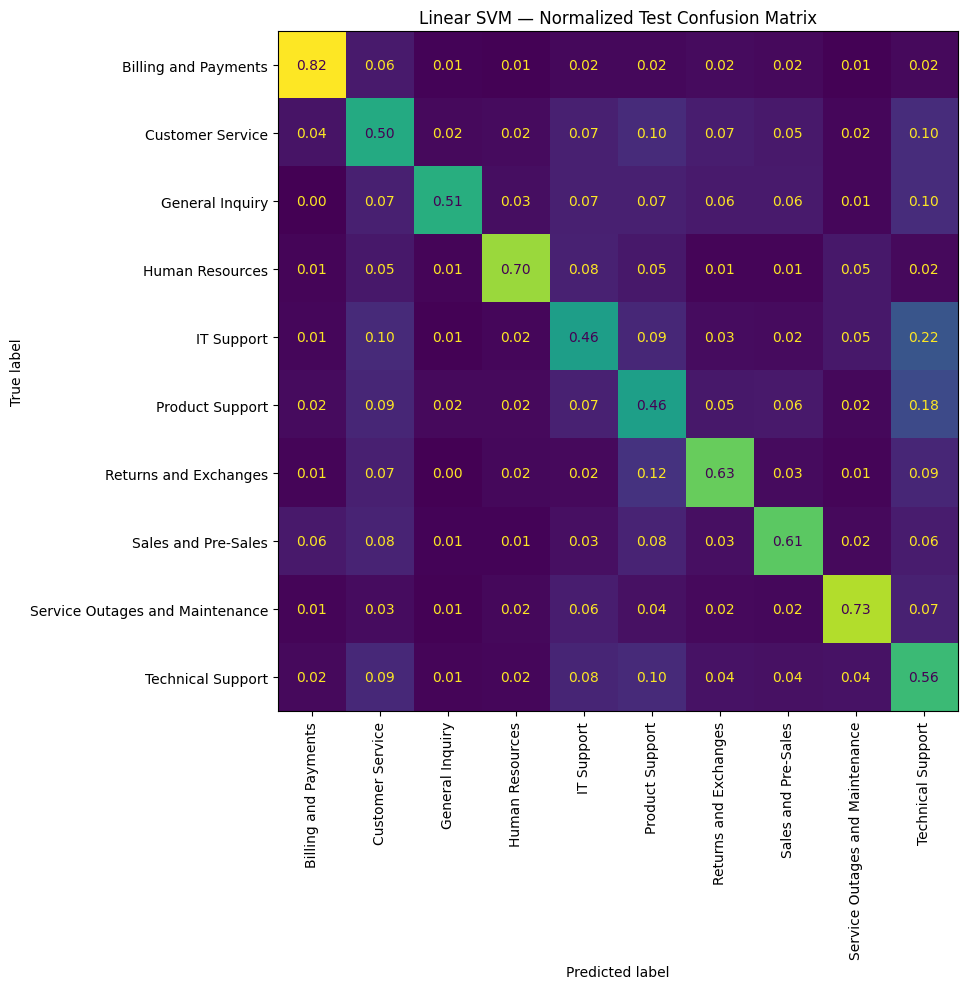

In [27]:
# Row-normalized confusion matrix
cm_normalized = confusion_matrix(
    y_test,
    y_test_pred,
    labels=class_labels,
    normalize="true",
)

fig, ax = plt.subplots(figsize=(12, 10))

display_normalized = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_labels,
)

display_normalized.plot(
    ax=ax,
    xticks_rotation=90,
    values_format=".2f",
    colorbar=False,
)

ax.set_title(
    "Linear SVM — Normalized Test Confusion Matrix"
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()
plt.savefig(
    "svm_confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [28]:
joblib.dump(
    final_model,
    "tfidf_linear_svm_baseline.joblib"
)

['tfidf_linear_svm_baseline.joblib']

### Final Baseline Conclusion

The tuned TF-IDF + Linear SVM pipeline was selected as the strongest
classical configuration evaluated in this notebook. It achieved a mean
cross-validation Macro F1 of **0.4801**, followed by a test accuracy of
**0.56** and a test Macro F1 of **0.5427** on the untouched test set.

The highest class-level performance was obtained for
`Billing and Payments` (F1 = **0.81**), followed by
`Service Outages and Maintenance` (F1 = **0.61**) and
`Technical Support` (F1 = **0.60**). These categories appear to contain
relatively distinctive lexical patterns.

The weakest results were observed for `General Inquiry` and
`Sales and Pre-Sales` (both F1 = **0.43**), followed by
`IT Support` (F1 = **0.47**). These classes are either underrepresented,
broadly defined, or semantically close to other support queues.

The train Macro F1 of **0.8620** remains substantially higher than the
test Macro F1 of **0.5427**, producing a generalization gap of **0.3193**.
This indicates that the model continues to overfit the training data,
despite regularization and cross-validation-based model selection.

The remaining errors are likely associated with class imbalance,
semantic overlap between queue definitions, short or ambiguous ticket
texts, insufficient examples for minority classes, and potentially
inconsistent labels. However, these explanations should be verified
through confusion-matrix analysis and manual label auditing rather than
inferred from model errors alone.

Overall, the model provides a strong and computationally efficient
classical baseline. Test-set predictions are exported with stable record
identifiers and can be merged with BERT predictions for manual label
auditing. A disagreement between a model prediction and the original
label does not by itself prove that the label is incorrect.